In [1]:
# =========================================================
# FULL SCRIPT FROM SCRATCH
# ODE + DATASET + NN + BALANCE CHECKS + PLOTS
# Variables: Keq2 and f1
# Fixed: Vr2 = 0.107
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error


# =========================================================
# 1. SIMULATION SETTINGS
# =========================================================

STARTTIME = 0.0       # min
STOPTIME = 480.0      # min, from description file
N_TIMEPOINTS = 2000

t_eval = np.linspace(STARTTIME, STOPTIME, N_TIMEPOINTS)


# =========================================================
# 2. BASE PARAMETERS
# =========================================================

BASE_PARAMS = {
    # Biomass
    "X_gCDW_L": 10.0,

    # Reaction 1: H -> hH
    "Vmax1_mmol_gCDW_min": 0.07,
    "Ks1_mM": 0.014,
    "Ki_H_1_mM": 16.7,

    # Reaction 2: hH <-> oH
    "Vr2_mmol_gCDW_min": 0.107,     # FIXED, experimentally defined
    "Ks_oH2_mM": 0.02,

    # Reaction 3a: oH -> aH
    "Vmax3a_mmol_gCDW_min": 0.591,
    "Ks_oH3a_mM": 0.33,
    "Ks_Ala_mM": 0.06,

    # Reaction 3b: oH -> dH
    "Vmax3b_mmol_gCDW_min": 0.06,
    "Ks_oH3b_mM": 0.042,
    "Ki_H_3b_mM": 0.3,

    # Feeds
    "f1_mM_min": 0.1,       # HAME feed
    "f2_mM_min": 1.0,       # alanine feed

    # Feed stop time
    "t1_min": 720.0
}


# =========================================================
# 3. INITIAL CONDITIONS
# =========================================================

INITIAL_ALA_mM = 1.0

y0 = [
    0.0,              # H_mM
    0.0,              # hH_mM
    0.0,              # oH_mM
    0.0,              # aH_mM
    0.0,              # dH_mM
    INITIAL_ALA_mM    # Ala_mM
]


# =========================================================
# 4. ODE SYSTEM
# =========================================================

def odes(t, y, p):
    H, hH, oH, aH, dH, Ala = y

    # Feeds
    F_HAME = p["f1_mM_min"] if t <= p["t1_min"] else 0.0
    F_Ala = p["f2_mM_min"] if t <= p["t1_min"] else 0.0

    X = p["X_gCDW_L"]

    # -------------------------
    # Reaction 1: H -> hH
    # -------------------------
    v1 = (
        p["Vmax1_mmol_gCDW_min"]
        * H
        / (p["Ks1_mM"] + H + (H ** 2) / p["Ki_H_1_mM"])
        * X
    )

    # -------------------------
    # Reaction 2: hH <-> oH
    # Vf2 = Vr2 * Keq2
    # -------------------------
    Vr2 = p["Vr2_mmol_gCDW_min"]
    Keq2 = p["Keq2_dimensionless"]
    Vf2 = Vr2 * Keq2

    v2 = (
        (Vf2 * hH - Vr2 * oH)
        / (p["Ks_oH2_mM"] + hH + oH)
        * X
    )

    # -------------------------
    # Reaction 3a: oH -> aH
    # -------------------------
    v3a = (
        p["Vmax3a_mmol_gCDW_min"]
        * oH
        / (p["Ks_oH3a_mM"] + oH)
        * Ala
        / (p["Ks_Ala_mM"] + Ala)
        * X
    )

    # -------------------------
    # Reaction 3b: oH -> dH
    # -------------------------
    v3b = (
        p["Vmax3b_mmol_gCDW_min"]
        * oH
        / (p["Ks_oH3b_mM"] + oH + (H ** 2) / p["Ki_H_3b_mM"])
        * X
    )

    v3 = v3a + v3b

    return [
        F_HAME - v1,        # dH/dt
        v1 - v2,            # dhH/dt
        v2 - v3a - v3b,     # doH/dt
        v3a,                # daH/dt
        v3b,                # ddH/dt
        F_Ala - v3          # dAla/dt, original description file
    ]


# =========================================================
# 5. DATASET GENERATION
# =========================================================

def generate_dataset(
    Keq2_values=np.arange(0.01, 0.151, 0.01),
    f1_values=np.arange(0.02, 0.121, 0.01),
    output_file="kinetic_dataset_Keq2_f1.csv"
):

    all_rows = []
    sim_id = 0

    for Keq2 in Keq2_values:
        for f1 in f1_values:

            sim_id += 1

            params = BASE_PARAMS.copy()
            params["Keq2_dimensionless"] = float(Keq2)
            params["f1_mM_min"] = float(f1)

            sol = solve_ivp(
                lambda t, y: odes(t, y, params),
                (STARTTIME, STOPTIME),
                y0,
                method="RK45",
                t_eval=t_eval,
                rtol=1e-6,
                atol=1e-9
            )

            if not sol.success:
                print(f"Solver failed: Keq2={Keq2}, f1={f1}")
                continue

            for i in range(len(sol.t)):

                H = sol.y[0, i]
                hH = sol.y[1, i]
                oH = sol.y[2, i]
                aH = sol.y[3, i]
                dH = sol.y[4, i]
                Ala = sol.y[5, i]

                time_min = sol.t[i]

                # Mass balance
                total_analytes = H + hH + oH + aH + dH
                expected_HAME_feed = f1 * min(time_min, params["t1_min"])
                mass_balance_error = expected_HAME_feed - total_analytes

                # Alanine balance
                # Because dAla/dt = F_ala - (v3a + v3b)
                expected_Ala = (
                    INITIAL_ALA_mM
                    + params["f2_mM_min"] * min(time_min, params["t1_min"])
                    - aH
                    - dH
                )

                Ala_balance_error = expected_Ala - Ala

                row = {
                    "sim_id": sim_id,
                    "time_min": time_min,

                    # ODE states
                    "H_mM": H,
                    "hH_mM": hH,
                    "oH_mM": oH,
                    "aH_mM": aH,
                    "dH_mM": dH,
                    "Ala_mM": Ala,

                    # Balance checks
                    "total_analytes_mM": total_analytes,
                    "expected_HAME_feed_mM": expected_HAME_feed,
                    "mass_balance_error_mM": mass_balance_error,

                    "expected_Ala_mM": expected_Ala,
                    "Ala_balance_error_mM": Ala_balance_error,
                }

                # Add all parameters
                for key, value in params.items():
                    row[key] = value

                all_rows.append(row)

    dataset = pd.DataFrame(all_rows)
    dataset.to_csv(output_file, index=False)

    print("Dataset generated")
    print("Total simulations:", sim_id)
    print("Total rows:", len(dataset))
    print("Saved:", output_file)

    return dataset


dataset = generate_dataset()

Dataset generated
Total simulations: 165
Total rows: 330000
Saved: kinetic_dataset_Keq2_f1.csv


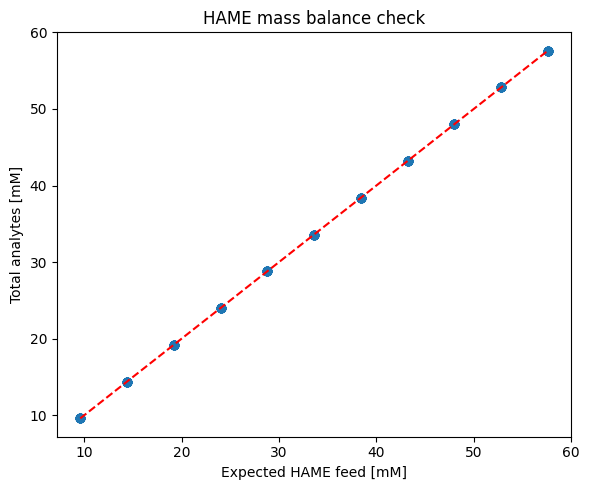

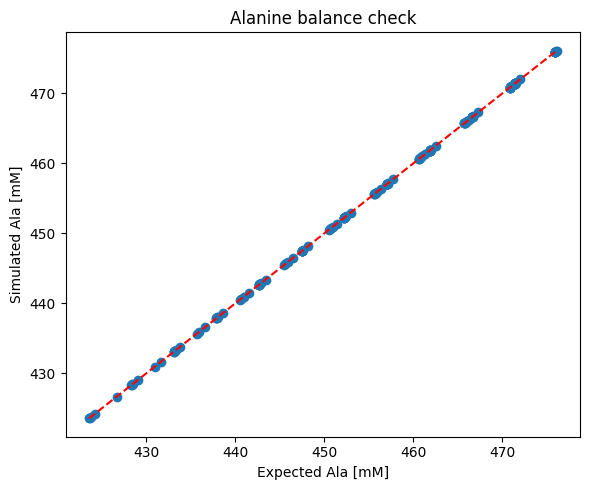

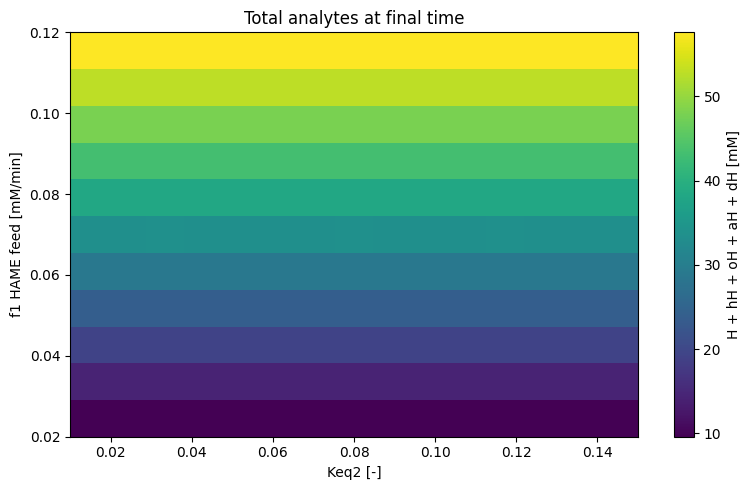

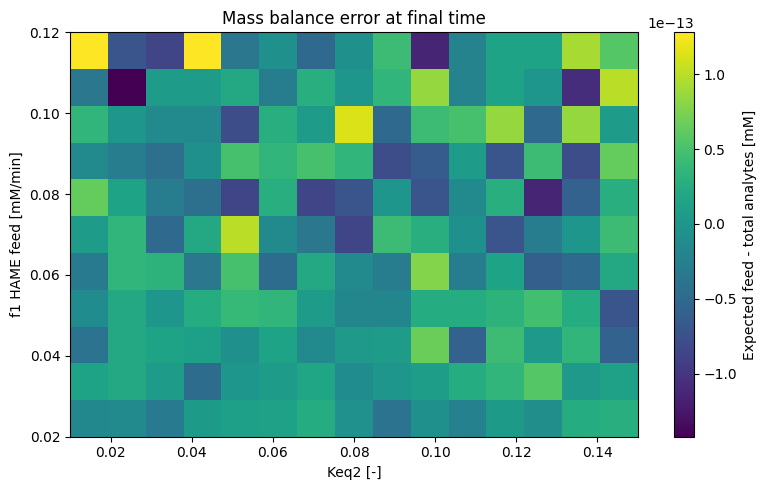

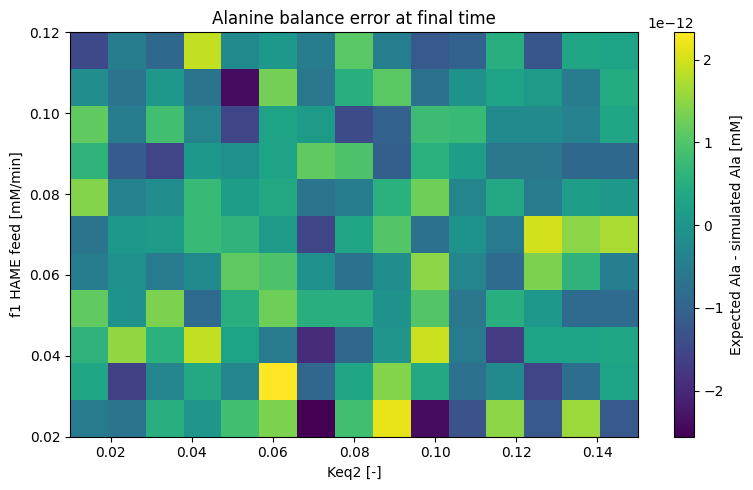

In [2]:
# =========================================================
# 6. FINAL TIME DATAFRAME
# =========================================================

final_df = (
    dataset
    .sort_values("time_min")
    .groupby("sim_id")
    .tail(1)
    .reset_index(drop=True)
)

final_df.to_csv("final_ODE_results_with_balance.csv", index=False)


# =========================================================
# 7. BALANCE CHECK PLOTS
# =========================================================

plt.figure(figsize=(6, 5))
plt.scatter(
    final_df["expected_HAME_feed_mM"],
    final_df["total_analytes_mM"]
)
min_val = min(final_df["expected_HAME_feed_mM"].min(), final_df["total_analytes_mM"].min())
max_val = max(final_df["expected_HAME_feed_mM"].max(), final_df["total_analytes_mM"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Expected HAME feed [mM]")
plt.ylabel("Total analytes [mM]")
plt.title("HAME mass balance check")
plt.tight_layout()
plt.savefig("mass_balance_check.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 5))
plt.scatter(
    final_df["expected_Ala_mM"],
    final_df["Ala_mM"]
)
min_val = min(final_df["expected_Ala_mM"].min(), final_df["Ala_mM"].min())
max_val = max(final_df["expected_Ala_mM"].max(), final_df["Ala_mM"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Expected Ala [mM]")
plt.ylabel("Simulated Ala [mM]")
plt.title("Alanine balance check")
plt.tight_layout()
plt.savefig("alanine_balance_check.png", dpi=300)
plt.show()


# =========================================================
# 8. HEATMAP: TOTAL ANALYTES AND BALANCE ERROR
# =========================================================

def plot_heatmap(final_df, value_col, title, cbar_label, filename):
    grid = final_df.pivot(
        index="f1_mM_min",
        columns="Keq2_dimensionless",
        values=value_col
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(
        grid.values,
        origin="lower",
        aspect="auto",
        extent=[
            grid.columns.min(),
            grid.columns.max(),
            grid.index.min(),
            grid.index.max()
        ]
    )
    plt.colorbar(label=cbar_label)
    plt.xlabel("Keq2 [-]")
    plt.ylabel("f1 HAME feed [mM/min]")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


plot_heatmap(
    final_df,
    "total_analytes_mM",
    "Total analytes at final time",
    "H + hH + oH + aH + dH [mM]",
    "heatmap_total_analytes.png"
)

plot_heatmap(
    final_df,
    "mass_balance_error_mM",
    "Mass balance error at final time",
    "Expected feed - total analytes [mM]",
    "heatmap_mass_balance_error.png"
)

plot_heatmap(
    final_df,
    "Ala_balance_error_mM",
    "Alanine balance error at final time",
    "Expected Ala - simulated Ala [mM]",
    "heatmap_alanine_balance_error.png"
)




Toxicity check:
False    165
Name: H_above_toxic_limit, dtype: int64


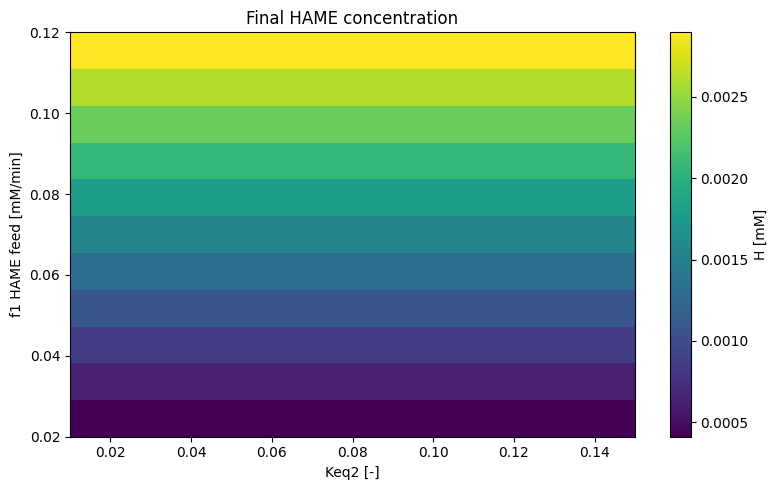

Epoch 000 | Loss = 0.220937
Epoch 010 | Loss = 0.001671
Epoch 020 | Loss = 0.001377
Epoch 030 | Loss = 0.001269
Epoch 040 | Loss = 0.001211
Epoch 050 | Loss = 0.001177
Epoch 060 | Loss = 0.001135
Epoch 070 | Loss = 0.001074


In [3]:

# =========================================================
# 9. TOXICITY CHECK FOR HAME
# =========================================================

H_TOXIC_LIMIT_mM = 2.7

final_df["H_above_toxic_limit"] = final_df["H_mM"] > H_TOXIC_LIMIT_mM

print("\nToxicity check:")
print(final_df["H_above_toxic_limit"].value_counts())


plot_heatmap(
    final_df,
    "H_mM",
    "Final HAME concentration",
    "H [mM]",
    "heatmap_H_final.png"
)


# =========================================================
# 10. NEURAL NETWORK DATA PREPARATION
# =========================================================

output_cols = [
    "H_mM",
    "hH_mM",
    "oH_mM",
    "aH_mM",
    "dH_mM",
    "Ala_mM"
]

input_cols = [
    "time_min",
    "Keq2_dimensionless",
    "f1_mM_min",
    "f2_mM_min",
    "Vr2_mmol_gCDW_min",
    "X_gCDW_L",
    "Vmax1_mmol_gCDW_min",
    "Ks1_mM",
    "Ki_H_1_mM",
    "Ks_oH2_mM",
    "Vmax3a_mmol_gCDW_min",
    "Ks_oH3a_mM",
    "Ks_Ala_mM",
    "Vmax3b_mmol_gCDW_min",
    "Ks_oH3b_mM",
    "Ki_H_3b_mM",
    "t1_min"
]

sim_ids = dataset["sim_id"].unique()

train_ids, test_ids = train_test_split(
    sim_ids,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df = dataset[dataset["sim_id"].isin(train_ids)].reset_index(drop=True)
test_df = dataset[dataset["sim_id"].isin(test_ids)].reset_index(drop=True)

X_train = train_df[input_cols].values
Y_train = train_df[output_cols].values

X_test = test_df[input_cols].values
Y_test = test_df[output_cols].values


# =========================================================
# 11. NORMALIZATION
# =========================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_test_scaled = y_scaler.transform(Y_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_scaled, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test_scaled, dtype=torch.float32)


# =========================================================
# 12. NEURAL NETWORK
# =========================================================

class TinyMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        return self.net(x)


model = TinyMLP(input_dim=X_train_t.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 80
batch_size = 2048


# =========================================================
# 13. TRAINING
# =========================================================

for epoch in range(epochs):

    model.train()
    perm = torch.randperm(X_train_t.size(0))

    epoch_losses = []

    for i in range(0, X_train_t.size(0), batch_size):

        idx = perm[i:i + batch_size]

        optimizer.zero_grad()

        pred = model(X_train_t[idx])
        loss = loss_fn(pred, Y_train_t[idx])

        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss = {np.mean(epoch_losses):.6f}")




Test-set performance:

H_mM
  R2   = 0.99751
  RMSE = 0.000040

hH_mM
  R2   = 0.99997
  RMSE = 0.048453

oH_mM
  R2   = 0.99723
  RMSE = 0.000052

aH_mM
  R2   = 0.99996
  RMSE = 0.037996

dH_mM
  R2   = 0.99997
  RMSE = 0.025418

Ala_mM
  R2   = 0.99999
  RMSE = 0.462261



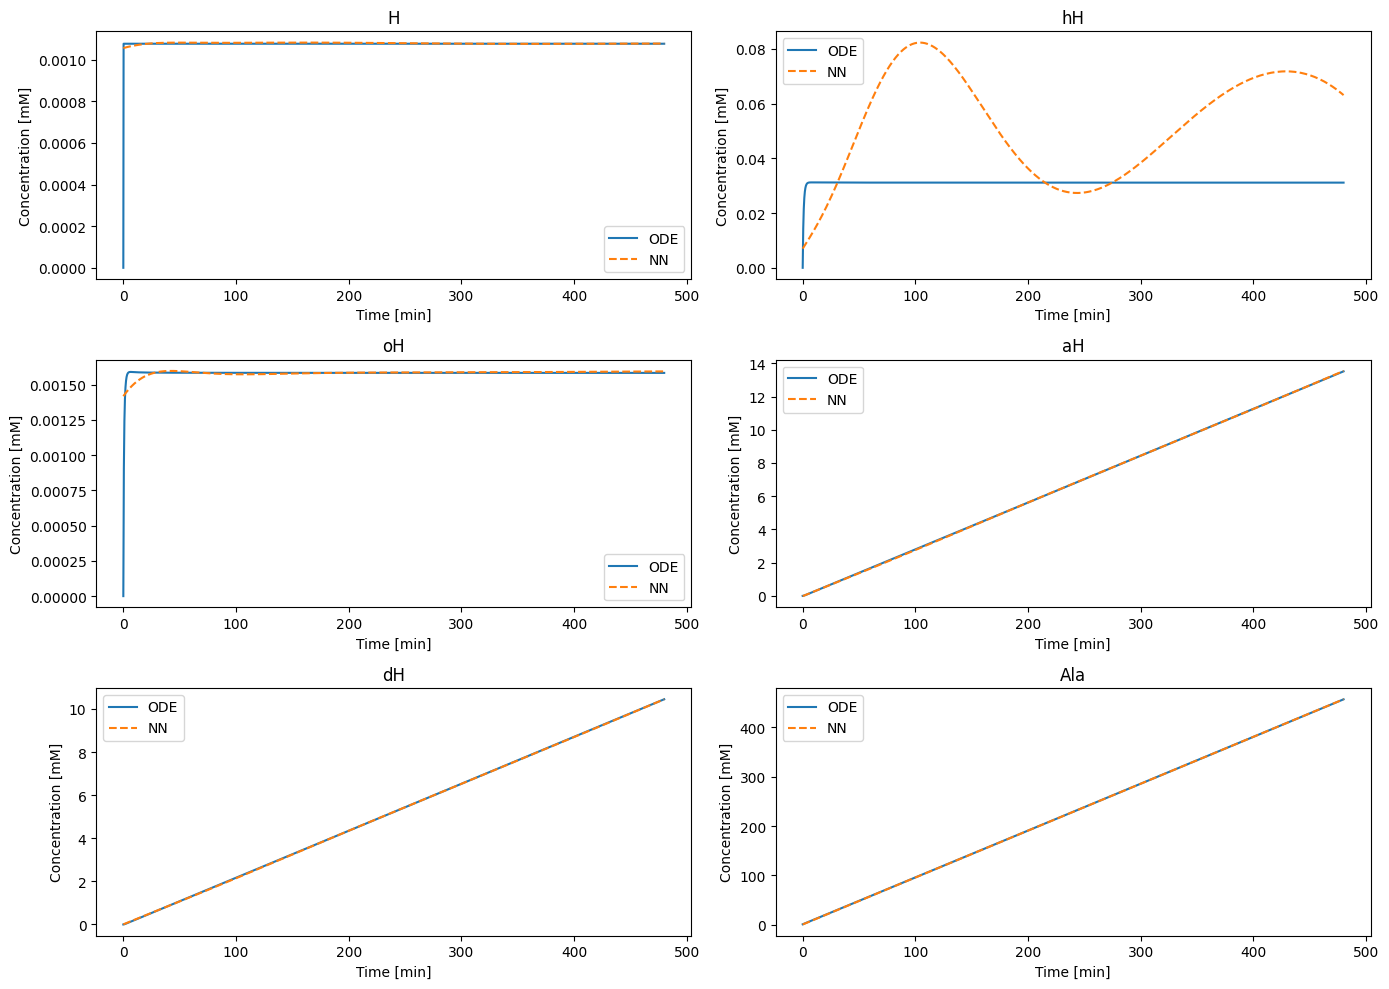


Final comparison columns:
Index(['f1_mM_min', 'Keq2_dimensionless', 'H_ode_mM', 'H_nn_mM', 'H_error_mM',
       'hH_ode_mM', 'hH_nn_mM', 'hH_error_mM', 'oH_ode_mM', 'oH_nn_mM',
       'oH_error_mM', 'aH_ode_mM', 'aH_nn_mM', 'aH_error_mM', 'dH_ode_mM',
       'dH_nn_mM', 'dH_error_mM', 'Ala_ode_mM', 'Ala_nn_mM', 'Ala_error_mM',
       'total_analytes_mM', 'expected_HAME_feed_mM', 'mass_balance_error_mM',
       'expected_Ala_mM', 'Ala_balance_error_mM'],
      dtype='object')


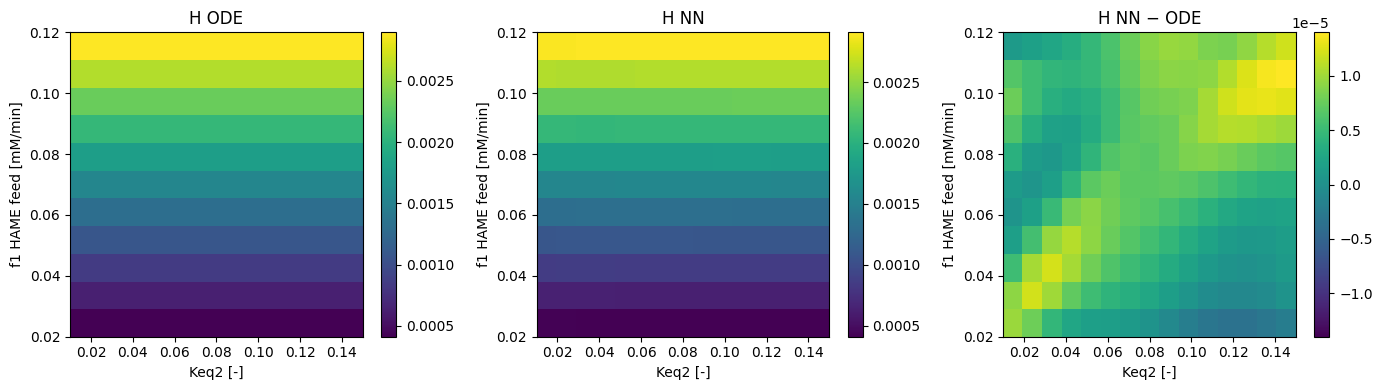

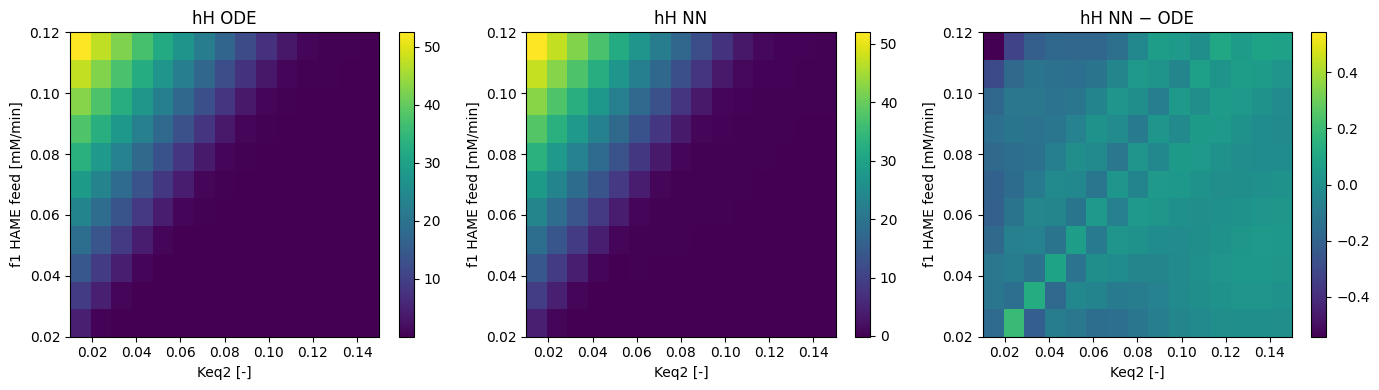

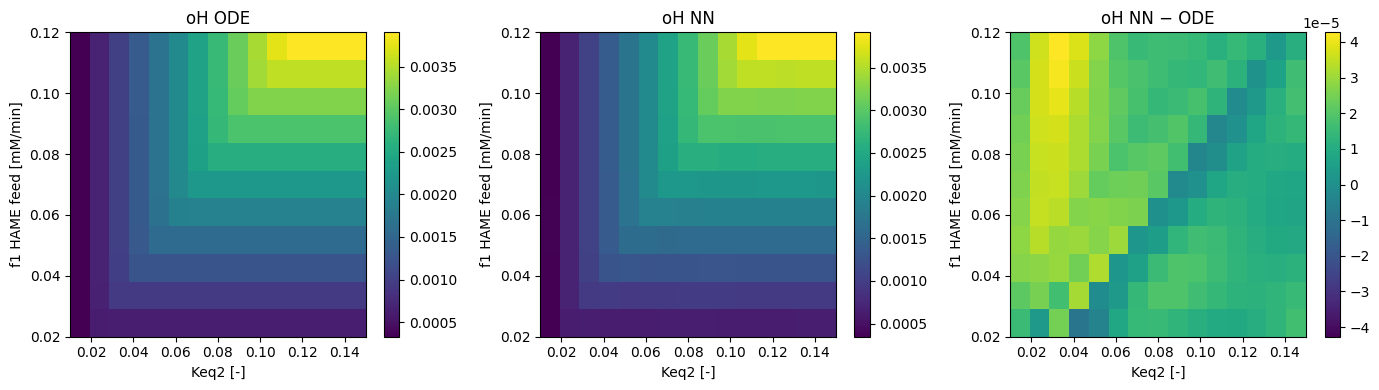

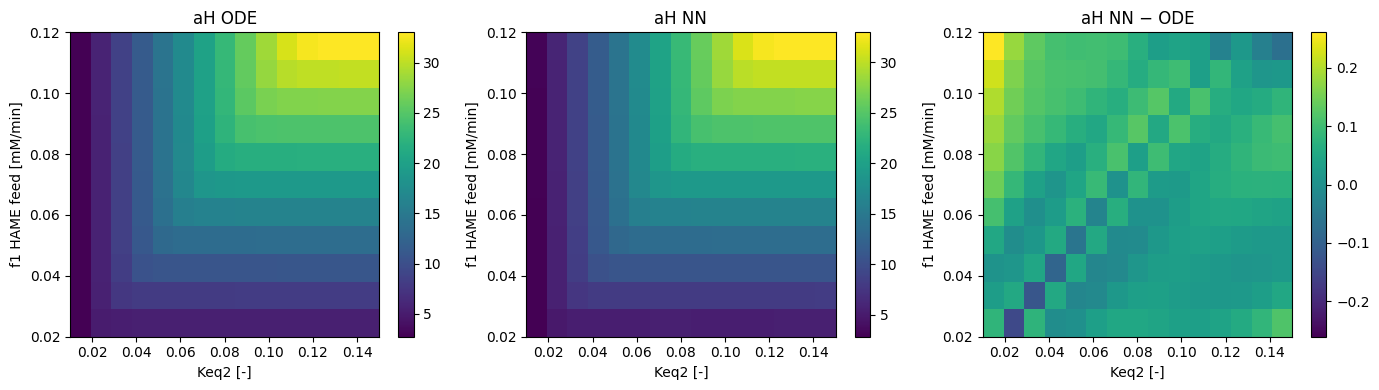

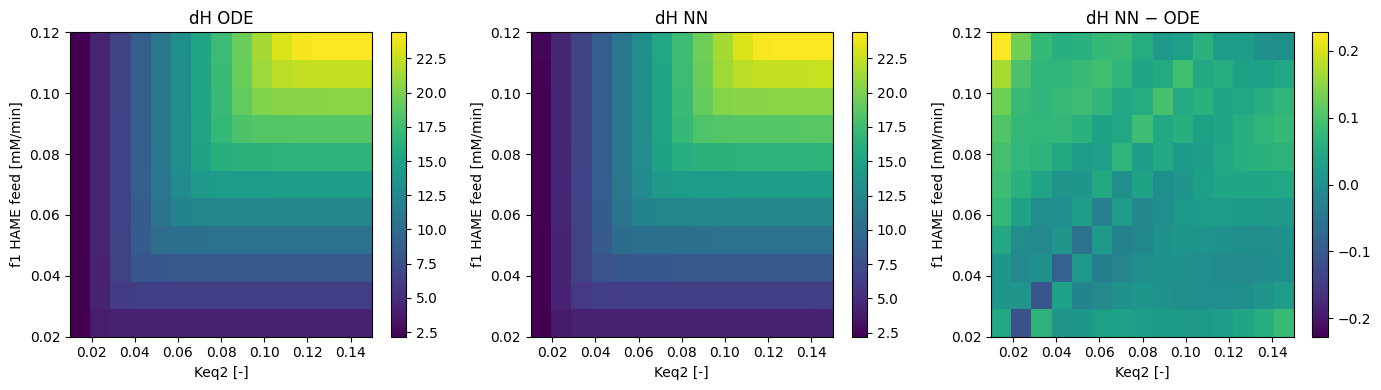

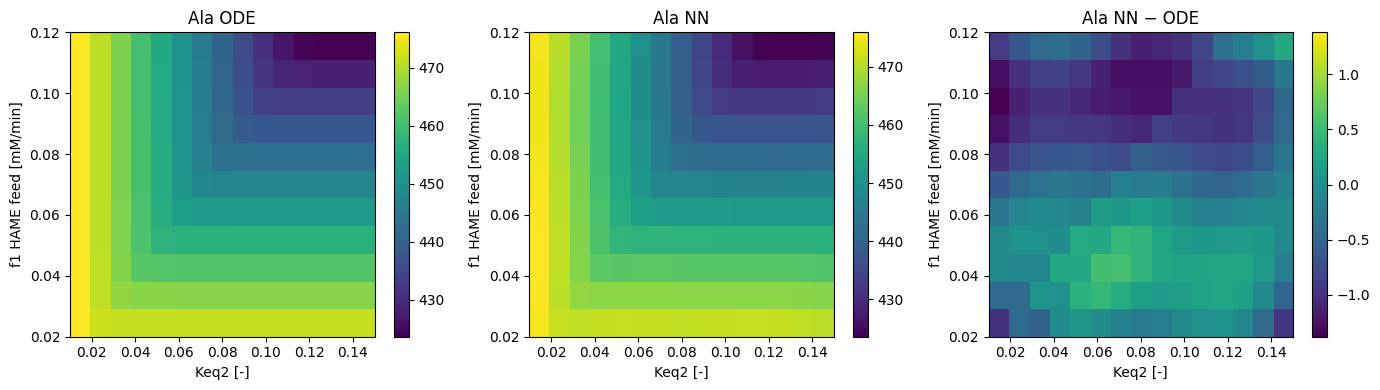

In [4]:
# =========================================================
# 14. TEST EVALUATION
# =========================================================

model.eval()

with torch.no_grad():
    Y_pred_scaled = model(X_test_t).numpy()

Y_pred = y_scaler.inverse_transform(Y_pred_scaled)
Y_true = y_scaler.inverse_transform(Y_test_t.numpy())

print("\nTest-set performance:\n")

for i, label in enumerate(output_cols):
    r2 = r2_score(Y_true[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_true[:, i], Y_pred[:, i]))

    print(label)
    print(f"  R2   = {r2:.5f}")
    print(f"  RMSE = {rmse:.6f}\n")


# =========================================================
# 15. TRUE VS NN TRAJECTORY EXAMPLE
# =========================================================

example_sim = test_ids[0]
true_traj = test_df[test_df["sim_id"] == example_sim].copy()

X_example = true_traj[input_cols].values
X_example_scaled = x_scaler.transform(X_example)
X_example_t = torch.tensor(X_example_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Y_example_scaled = model(X_example_t).numpy()

Y_example = y_scaler.inverse_transform(Y_example_scaled)

time = true_traj["time_min"].values

state_names = ["H", "hH", "oH", "aH", "dH", "Ala"]

plt.figure(figsize=(14, 10))

for i, state in enumerate(state_names):
    plt.subplot(3, 2, i + 1)
    plt.plot(time, true_traj[f"{state}_mM"].values, label="ODE")
    plt.plot(time, Y_example[:, i], "--", label="NN")
    plt.title(state)
    plt.xlabel("Time [min]")
    plt.ylabel("Concentration [mM]")
    plt.legend()

plt.tight_layout()
plt.savefig("example_trajectory_ODE_vs_NN.png", dpi=300)
plt.show()


# =========================================================
# 16. PREDICT ALL DATASET POINTS
# =========================================================

with torch.no_grad():
    X_all = dataset[input_cols].values
    X_all_scaled = x_scaler.transform(X_all)
    X_all_t = torch.tensor(X_all_scaled, dtype=torch.float32)

    Y_all_scaled = model(X_all_t).numpy()
    Y_all = y_scaler.inverse_transform(Y_all_scaled)

data_cmp = dataset.copy()

data_cmp["H_nn_mM"] = Y_all[:, 0]
data_cmp["hH_nn_mM"] = Y_all[:, 1]
data_cmp["oH_nn_mM"] = Y_all[:, 2]
data_cmp["aH_nn_mM"] = Y_all[:, 3]
data_cmp["dH_nn_mM"] = Y_all[:, 4]
data_cmp["Ala_nn_mM"] = Y_all[:, 5]

data_cmp["H_error_mM"] = data_cmp["H_nn_mM"] - data_cmp["H_mM"]
data_cmp["hH_error_mM"] = data_cmp["hH_nn_mM"] - data_cmp["hH_mM"]
data_cmp["oH_error_mM"] = data_cmp["oH_nn_mM"] - data_cmp["oH_mM"]
data_cmp["aH_error_mM"] = data_cmp["aH_nn_mM"] - data_cmp["aH_mM"]
data_cmp["dH_error_mM"] = data_cmp["dH_nn_mM"] - data_cmp["dH_mM"]
data_cmp["Ala_error_mM"] = data_cmp["Ala_nn_mM"] - data_cmp["Ala_mM"]

data_cmp.to_csv("full_ODE_NN_error_all_timepoints.csv", index=False)


# =========================================================
# 17. FINAL COMPARISON TABLE
# =========================================================

rows = []

for (f1, Keq2), df in data_cmp.groupby(["f1_mM_min", "Keq2_dimensionless"]):

    df = df.sort_values("time_min")

    row = {
        "f1_mM_min": f1,
        "Keq2_dimensionless": Keq2,
    }

    for state in ["H", "hH", "oH", "aH", "dH", "Ala"]:

        row[f"{state}_ode_mM"] = df[f"{state}_mM"].iloc[-1]
        row[f"{state}_nn_mM"] = df[f"{state}_nn_mM"].iloc[-1]
        row[f"{state}_error_mM"] = df[f"{state}_error_mM"].iloc[-1]

    row["total_analytes_mM"] = df["total_analytes_mM"].iloc[-1]
    row["expected_HAME_feed_mM"] = df["expected_HAME_feed_mM"].iloc[-1]
    row["mass_balance_error_mM"] = df["mass_balance_error_mM"].iloc[-1]

    row["expected_Ala_mM"] = df["expected_Ala_mM"].iloc[-1]
    row["Ala_balance_error_mM"] = df["Ala_balance_error_mM"].iloc[-1]

    rows.append(row)

final_cmp_df = pd.DataFrame(rows)

final_cmp_df.to_csv("final_comparison_ODE_NN_errors.csv", index=False)

print("\nFinal comparison columns:")
print(final_cmp_df.columns)


# =========================================================
# 18. ODE vs NN vs ERROR HEATMAPS FOR ALL OUTPUTS
# =========================================================

output_states = ["H", "hH", "oH", "aH", "dH", "Ala"]

for state in output_states:

    ODE_grid = final_cmp_df.pivot(
        index="f1_mM_min",
        columns="Keq2_dimensionless",
        values=f"{state}_ode_mM"
    )

    NN_grid = final_cmp_df.pivot(
        index="f1_mM_min",
        columns="Keq2_dimensionless",
        values=f"{state}_nn_mM"
    )

    ERR_grid = final_cmp_df.pivot(
        index="f1_mM_min",
        columns="Keq2_dimensionless",
        values=f"{state}_error_mM"
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    surfaces = [ODE_grid, NN_grid, ERR_grid]
    titles = [
        f"{state} ODE",
        f"{state} NN",
        f"{state} NN − ODE"
    ]

    vmax_err = np.max(np.abs(ERR_grid.values))

    for i, (Z, title) in enumerate(zip(surfaces, titles)):

        ax = axes[i]

        if i == 2:
            im = ax.imshow(
                Z.values,
                origin="lower",
                aspect="auto",
                vmin=-vmax_err,
                vmax=vmax_err,
                extent=[
                    Z.columns.min(),
                    Z.columns.max(),
                    Z.index.min(),
                    Z.index.max()
                ]
            )
        else:
            im = ax.imshow(
                Z.values,
                origin="lower",
                aspect="auto",
                extent=[
                    Z.columns.min(),
                    Z.columns.max(),
                    Z.index.min(),
                    Z.index.max()
                ]
            )

        ax.set_title(title)
        ax.set_xlabel("Keq2 [-]")
        ax.set_ylabel("f1 HAME feed [mM/min]")

        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.savefig(f"{state}_ODE_vs_NN_error.png", dpi=300)
    plt.show()


